<a href="https://colab.research.google.com/github/maikol0629/dl_voice_command_cl/blob/main/05%20-%20arquitectura%20transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo Transformer: Spectrogram Encoder con RoPE para Clasificación de Comandos de Voz

In [1]:
# Colab setup
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os
    try:
        from google.colab import userdata
        os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
        os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
    except Exception:
        pass

    !pip install -q kagglehub torch torchaudio pandas numpy matplotlib scikit-learn librosa soundfile audioread numba
    import kagglehub
    import shutil

    try:
        data_path = kagglehub.competition_download("voice-commands-classification-2026")
    except Exception as e:
        print("Error al descargar de Kaggle. Asegúrate de configurar KAGGLE_USERNAME y KAGGLE_KEY en tus Colab Secrets.")
        raise e

    if not os.path.exists('data'):
        os.symlink(data_path, 'data')

    if not os.path.exists('dl_voice_command_cl'):
        !git clone https://github.com/maikol0629/dl_voice_command_cl.git

    for f in ['train_metadata.csv', 'test_metadata.csv']:
        src = os.path.join('dl_voice_command_cl', f)
        if os.path.exists(src) and not os.path.exists(f):
            shutil.copy(src, '.')
    for f in ['models.py', 'data.py']:
        src = os.path.join('dl_voice_command_cl', f)
        if os.path.exists(src) and not os.path.exists(f):
            shutil.copy(src, '.')

    DATA_PATH = os.path.join(data_path, 'train')
else:
    DATA_PATH = './data/train'


100%|██████████| 3.31G/3.31G [02:58<00:00, 19.9MB/s]

Extracting files...


Cloning into 'dl_voice_command_cl'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 94 (delta 49), reused 49 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (94/94), 2.91 MiB | 2.50 MiB/s, done.
Resolving deltas: 100% (49/49), done.


In [2]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from models import AudioToMelSpectrogram, SpectrogramTransformer
from data import load_data
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [3]:
SAMPLE_RATE = 16000
BATCH_SIZE = 64
EPOCHS = 30
LR = 4.37e-04
N_CLASSES = 35
N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 256
D_MODEL = 120
N_HEADS = 6
N_LAYERS = 4
PATIENCE = 5
SEED = 42
VAL_SIZE = 0.2

np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
# VoiceCommandsDataset is now imported from data.py


In [4]:
AUDIO_DIR = os.path.join(DATA_PATH, 'train', 'train')

train_loader, val_loader, label_encoder, num_classes = load_data(
    train_metadata_csv='train_metadata.csv',
    train_audio_dir=AUDIO_DIR,
    val_size=VAL_SIZE, seed=SEED,
    batch_size=BATCH_SIZE,
)

total = len(train_loader.dataset) + len(val_loader.dataset)
print(f"Total muestras: {total}")
print(f"Train: {len(train_loader.dataset)} | Val: {len(val_loader.dataset)}")
print(f"Numero de clases: {num_classes}")
print("Clases:", list(label_encoder.classes_))

Total muestras: 95246
Train: 76196 | Val: 19050
Numero de clases: 35
Clases: ['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']


In [5]:
# Crear transformación a Mel-spectrogram
audio_transform = AudioToMelSpectrogram(
    sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
).to(device)


In [ ]:
# Attention, FFN, and Transformer layers are now imported from models.py


In [ ]:
# SpectrogramTransformer is now imported from models.py


In [6]:
model = SpectrogramTransformer(
    num_classes=N_CLASSES, dim=D_MODEL, depth=N_LAYERS, heads=N_HEADS
).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParametros entrenables: {total_params:,}")

SpectrogramTransformer(
  (proj): Sequential(
    (0): Linear(in_features=64, out_features=120, bias=True)
    (1): LayerNorm((120,), eps=1e-05, elementwise_affine=True)
  )
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (norm1): LayerNorm((120,), eps=1e-05, elementwise_affine=True)
      (attn): RoPESelfAttention(
        (qkv): Linear(in_features=120, out_features=360, bias=True)
        (proj): Linear(in_features=120, out_features=120, bias=True)
        (rope): RotaryPositionalEmbedding()
      )
      (norm2): LayerNorm((120,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=120, out_features=480, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=480, out_features=120, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((120,), eps=1e-05, elementwise_affine=True)
  (cla

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_losses = []
train_accs = []
val_accs = []

In [11]:
for epoch in range(EPOCHS):
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for waveforms, labels in train_loader:
        waveforms = waveforms.to(device)
        labels = labels.to(device)
        mels = audio_transform(waveforms)
        optimizer.zero_grad()
        outputs = model(mels)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss_sum += loss.item() * mels.size(0)
        preds = outputs.argmax(dim=1)
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

    scheduler.step()

    epoch_train_loss = train_loss_sum / train_total
    epoch_train_acc = train_correct / train_total

    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for waveforms, labels in val_loader:
            waveforms = waveforms.to(device)
            labels = labels.to(device)
            mels = audio_transform(waveforms)
            outputs = model(mels)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * mels.size(0)
            preds = outputs.argmax(dim=1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    epoch_val_loss = val_loss_sum / val_total
    epoch_val_acc = val_correct / val_total

    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS:02d} | "
          f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc*100:.2f}%")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_transformer.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping en epoca {epoch+1}")
            break

Epoch 01/30 | Train Loss: 0.5326 Acc: 84.59% | Val Loss: 0.4095 Acc: 87.75%
Epoch 02/30 | Train Loss: 0.3954 Acc: 88.58% | Val Loss: 0.3218 Acc: 90.41%
Epoch 03/30 | Train Loss: 0.3306 Acc: 90.41% | Val Loss: 0.2768 Acc: 91.96%
Epoch 04/30 | Train Loss: 0.2887 Acc: 91.49% | Val Loss: 0.2782 Acc: 91.74%
Epoch 05/30 | Train Loss: 0.2613 Acc: 92.30% | Val Loss: 0.2789 Acc: 91.85%
Epoch 06/30 | Train Loss: 0.2417 Acc: 92.93% | Val Loss: 0.2557 Acc: 92.59%
Epoch 07/30 | Train Loss: 0.2190 Acc: 93.59% | Val Loss: 0.2447 Acc: 93.24%
Epoch 08/30 | Train Loss: 0.2015 Acc: 94.07% | Val Loss: 0.2265 Acc: 93.59%
Epoch 09/30 | Train Loss: 0.1810 Acc: 94.50% | Val Loss: 0.2309 Acc: 93.65%
Epoch 10/30 | Train Loss: 0.1701 Acc: 94.93% | Val Loss: 0.2162 Acc: 93.92%
Epoch 11/30 | Train Loss: 0.1526 Acc: 95.40% | Val Loss: 0.2273 Acc: 94.10%
Epoch 12/30 | Train Loss: 0.1399 Acc: 95.79% | Val Loss: 0.2222 Acc: 94.31%
Epoch 13/30 | Train Loss: 0.1247 Acc: 96.20% | Val Loss: 0.2202 Acc: 94.36%
Epoch 14/30 

In [12]:
model.load_state_dict(torch.load('best_transformer.pth', map_location=device))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for waveforms, labels in val_loader:
        waveforms = waveforms.to(device)
        mels = audio_transform(waveforms)
        outputs = model(mels)
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds.tolist())
        y_true.extend(labels.numpy().tolist())

val_acc_final = (np.array(y_true) == np.array(y_pred)).mean()
print(f"Accuracy final en validacion: {val_acc_final*100:.2f}%")

Accuracy final en validacion: 94.90%


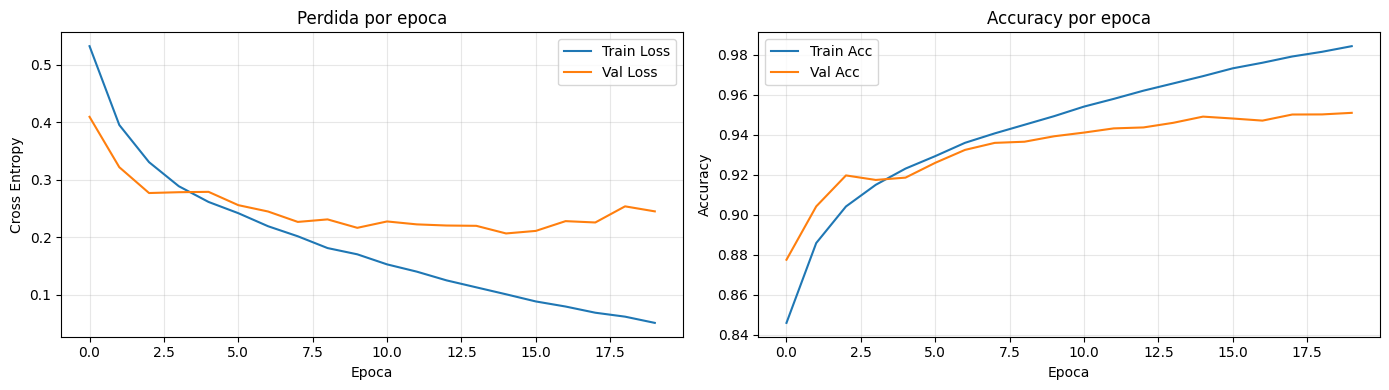

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Perdida por epoca')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Cross Entropy')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(train_accs, label='Train Acc')
axes[1].plot(val_accs, label='Val Acc')
axes[1].set_title('Accuracy por epoca')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

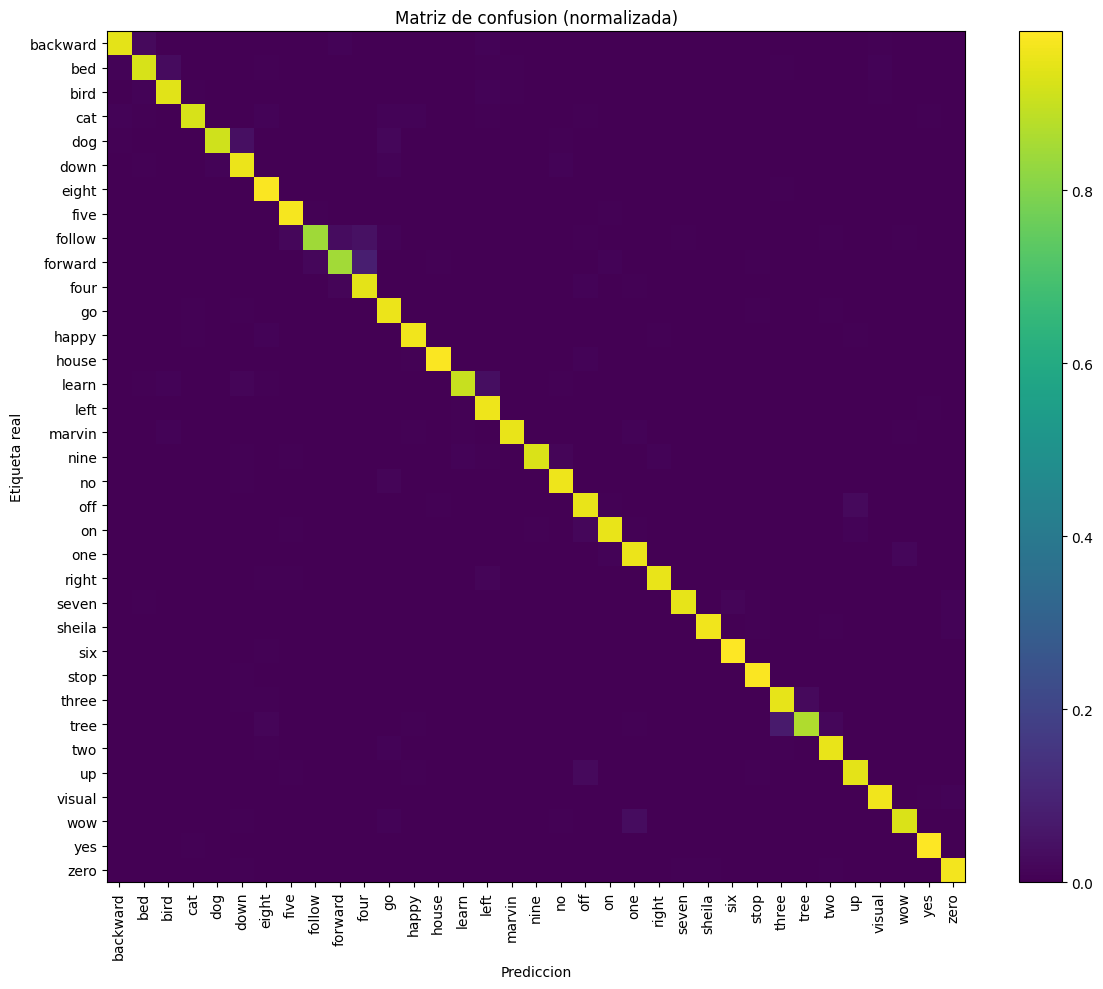

Reporte de clasificacion (validacion):
              precision    recall  f1-score   support

    backward       0.93      0.94      0.94       296
         bed       0.89      0.92      0.91       363
        bird       0.93      0.94      0.94       373
         cat       0.92      0.92      0.92       364
         dog       0.95      0.91      0.93       383
        down       0.92      0.95      0.94       702
       eight       0.94      0.98      0.96       683
        five       0.95      0.97      0.96       731
      follow       0.94      0.84      0.89       284
     forward       0.91      0.85      0.88       278
        four       0.94      0.94      0.94       674
          go       0.93      0.95      0.94       700
       happy       0.94      0.96      0.95       368
       house       0.97      0.98      0.98       381
       learn       0.92      0.90      0.91       281
        left       0.93      0.96      0.94       683
      marvin       0.97      0.95      0.9

In [14]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(12, 10))
plt.imshow(cm_norm, interpolation='nearest', aspect='auto')
plt.title('Matriz de confusion (normalizada)')
plt.colorbar()

tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=90)
plt.yticks(tick_marks, label_encoder.classes_)
plt.xlabel('Prediccion')
plt.ylabel('Etiqueta real')
plt.tight_layout()
plt.show()

print('Reporte de clasificacion (validacion):')
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))

## Conclusiones

El modelo Transformer entrenado para la clasificación de comandos de voz ha demostrado un rendimiento prometedor. Tras 20 épocas de entrenamiento con _early stopping_, se lograron los siguientes resultados:

-   **Pérdida (Loss):** La pérdida de entrenamiento final fue de aproximadamente 0.0507, mientras que la pérdida de validación final fue de 0.2449. Se observó una tendencia a la baja en ambas pérdidas, con el modelo deteniéndose en la época 20 debido al _early stopping_ cuando la pérdida de validación dejó de mejorar.
-   **Precisión (Accuracy):** El modelo alcanzó una precisión de entrenamiento del 98.43% y una precisión de validación final del **94.90%**. Esto indica que el modelo generaliza bien a datos no vistos.
-   **Matriz de Confusión y Reporte de Clasificación:** La matriz de confusión normalizada y el reporte de clasificación muestran que el modelo tiene una alta precisión, recall y f1-score para la mayoría de las clases, con valores cercanos al 95% o superiores. Algunas clases, como 'follow', 'forward', 'learn' y 'tree', tuvieron un rendimiento ligeramente inferior en términos de recall, lo que podría indicar cierta dificultad en la clasificación de esos comandos específicos.

En general, el modelo Transformer con *Spectrogram Encoder* y *RoPE* ha demostrado ser eficaz para la tarea de clasificación de comandos de voz, logrando una alta precisión en el conjunto de validación. La visualización de las curvas de pérdida y precisión a lo largo de las épocas confirma que el entrenamiento fue estable y que el _early stopping_ ayudó a prevenir el sobreajuste.